## Centralizando impotação de biibliotecas


In [36]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
import numpy as np
from sklearn.linear_model import LinearRegression

## Analise exploratoria dos dados

In [2]:
data = pd.read_csv('Salary_dataset.csv')

In [3]:
data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [5]:
data.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [6]:
data.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


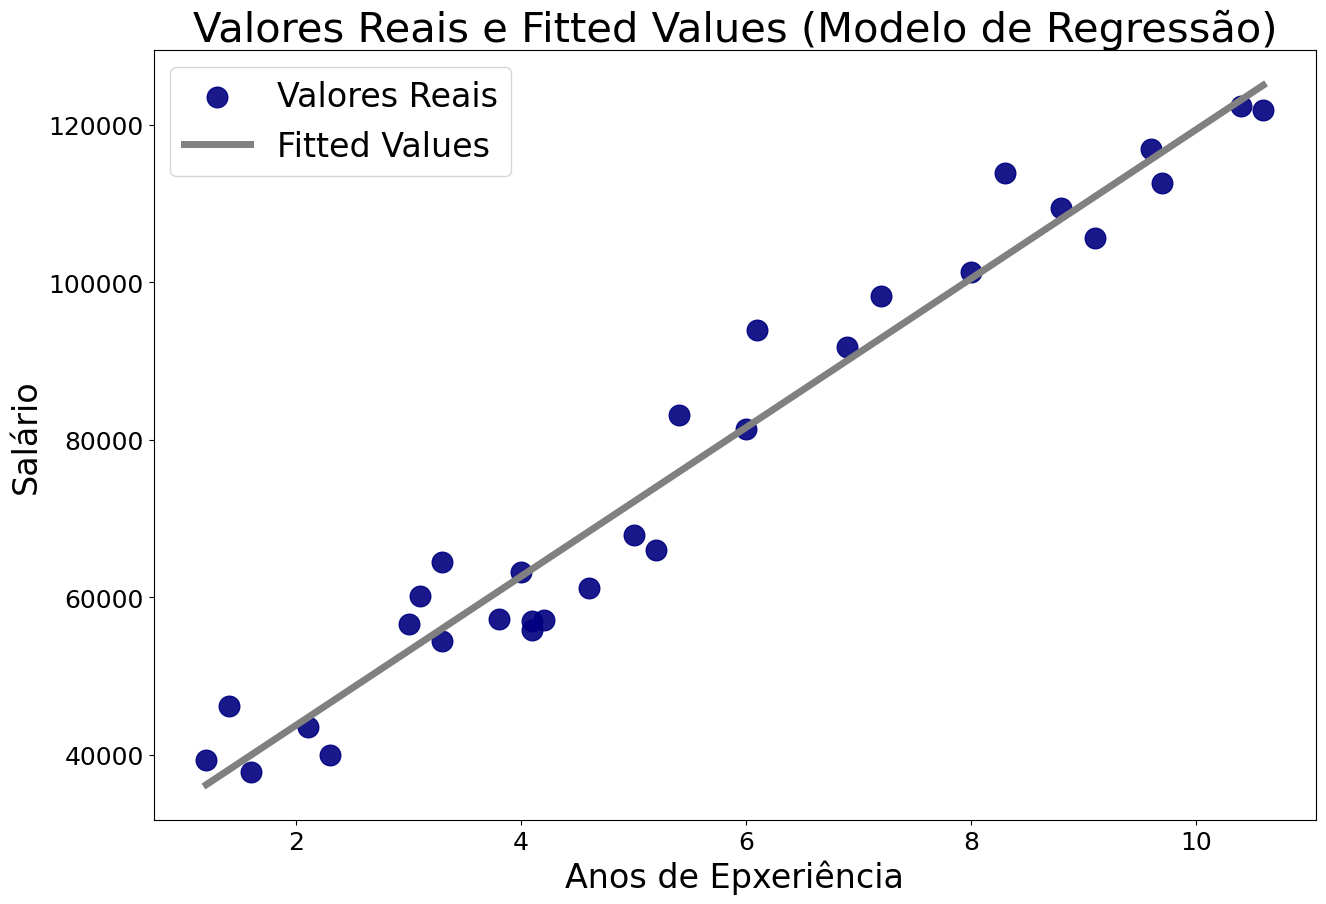

In [ ]:
plt.figure(figsize=(15,10))
sns.regplot(data=data, x='YearsExperience', y='Salary', marker='o', ci=False,
            scatter_kws={"color":'navy', 'alpha':0.9, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('Valores Reais e Fitted Values (Modelo de Regressão)', fontsize=30)
plt.xlabel('Anos de Epxeriência', fontsize=24)
plt.ylabel('Salário', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(['Valores Reais', 'Fitted Values'], fontsize=24, loc='upper left')
plt.show()

## Modelo com stats model

In [12]:
modelo = sm.OLS.from_formula('Salary ~ YearsExperience', data).fit()

In [15]:
display(modelo.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.14e-20
Time:                        23:29:25   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        2.485e+04   2306.654     10.772      0.000    2.01e+04    2.96e+04
YearsExperience  9449.9623    378.755     24.950      0.000    8674.119    1.02e+04
==============================================================================
Omnibus:                        2.140   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.569
Skew:                           0.363   Prob(JB):                        0.456
Kurtosis:                       2.147   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
data['yhat'] = modelo.fittedvalues
data['residuos'] = modelo.resid
data

,Unnamed: 0,YearsExperience,Salary,yhat,residuos
0,0,1.2,39344.0,36188.158752,3155.841248
1,1,1.4,46206.0,38078.151217,8127.848783
2,2,1.6,37732.0,39968.143681,-2236.143681
3,3,2.1,43526.0,44693.124842,-1167.124842
4,4,2.3,39892.0,46583.117306,-6691.117306
5,5,3.0,56643.0,53198.090931,3444.909069
6,6,3.1,60151.0,54143.087163,6007.912837
7,7,3.3,54446.0,56033.079627,-1587.079627
8,8,3.3,64446.0,56033.079627,8412.920373
9,9,3.8,57190.0,60758.060788,-3568.060788


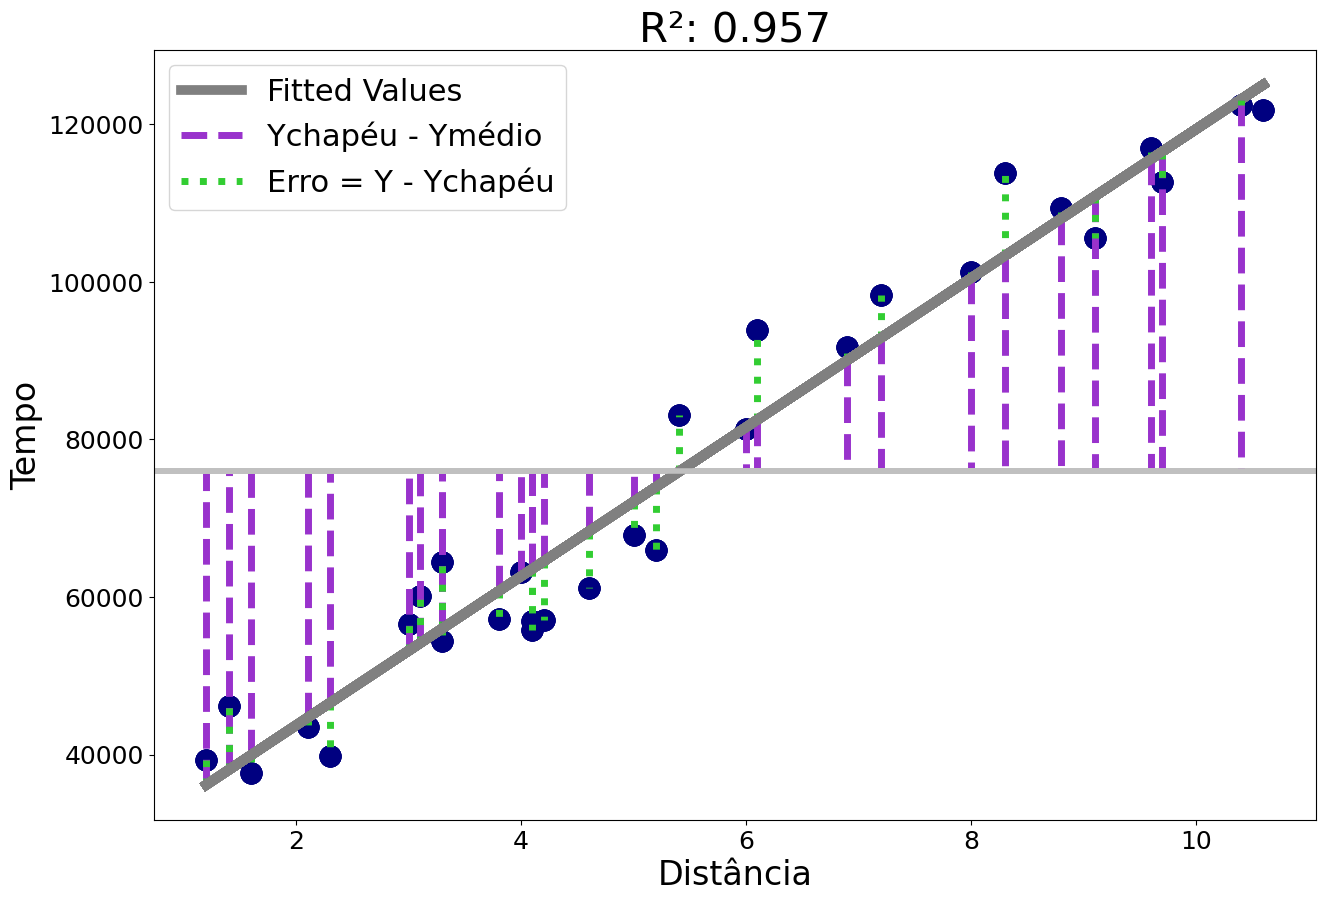

In [ ]:
plt.figure(figsize=(15,10))
y = data['Salary']
yhat = data['yhat']
x = data['YearsExperience']
mean = np.full(x.shape[0] , y.mean(), dtype=int)

for i in range(len(x)-1):
    plt.plot(x, yhat, color='grey', linewidth=7)
    plt.plot([x[i], x[i]], [yhat[i], mean[i]], '--', color='darkorchid',
             linewidth=5)
    plt.plot([x[i], x[i]], [yhat[i], y[i]],':', color='limegreen', linewidth=5)
    plt.scatter(x, y, color='navy', s=220, alpha=0.2)
    plt.axhline(y = y.mean(), color = 'silver', linestyle = '-', linewidth=4)
    plt.title('R²: ' + str(round(modelo.rsquared, 4)), fontsize=30)
    plt.xlabel('Distância', fontsize=24)
    plt.ylabel('Tempo', fontsize=24)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(['Fitted Values', 'Ychapéu - Ymédio', 'Erro = Y - Ychapéu'],
               fontsize=22, loc='upper left')
plt.show()

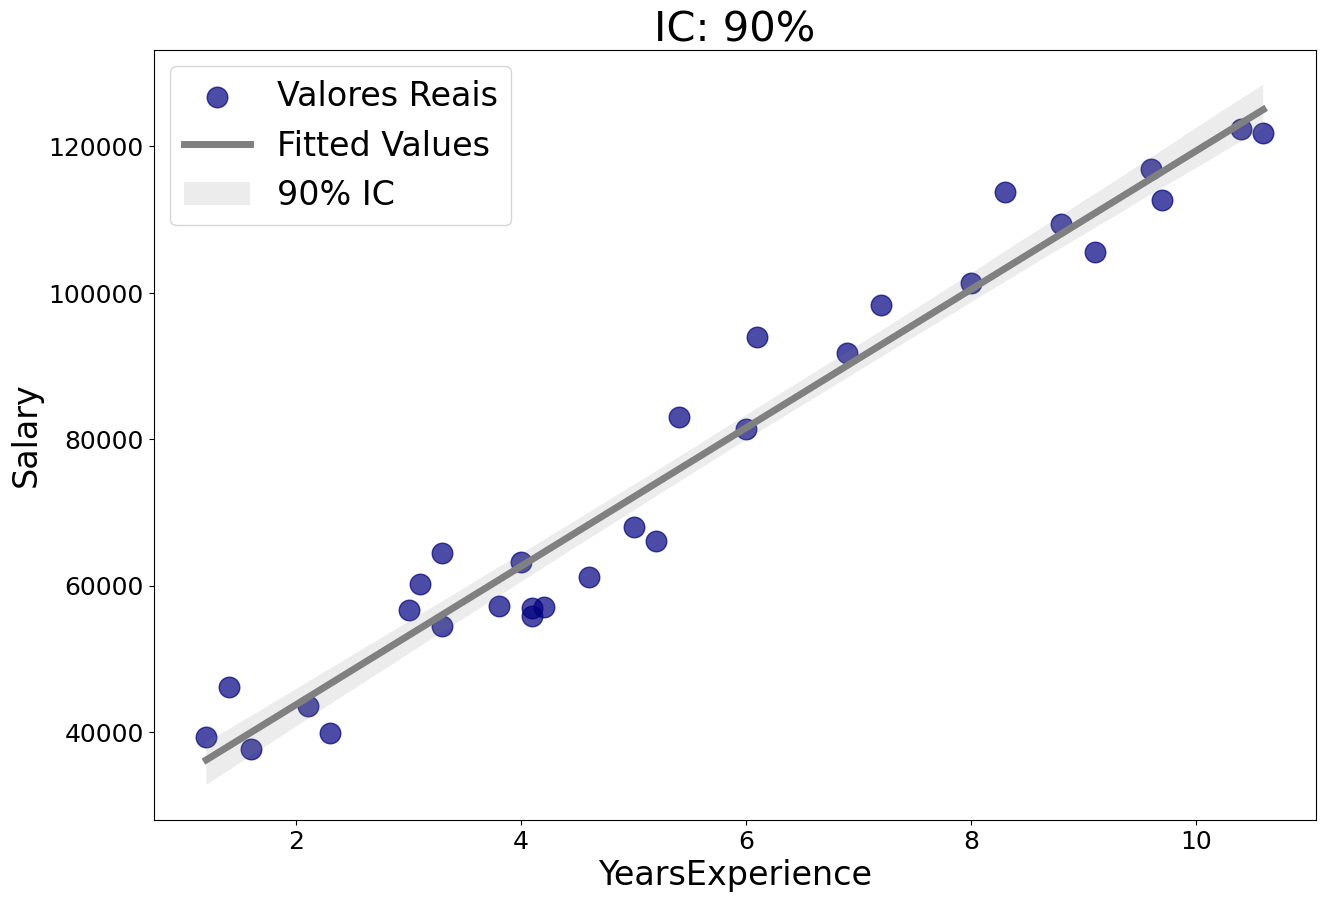

In [22]:
plt.figure(figsize=(15,10))
sns.regplot(data=data, x='YearsExperience', y='Salary', marker='o', ci=90,
            scatter_kws={"color":'navy', 'alpha':0.7, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('IC: 90%', fontsize=30)
plt.xlabel('YearsExperience', fontsize=24)
plt.ylabel('Salary', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(['Valores Reais', 'Fitted Values', '90% IC'],
           fontsize=24, loc='upper left')
plt.show()

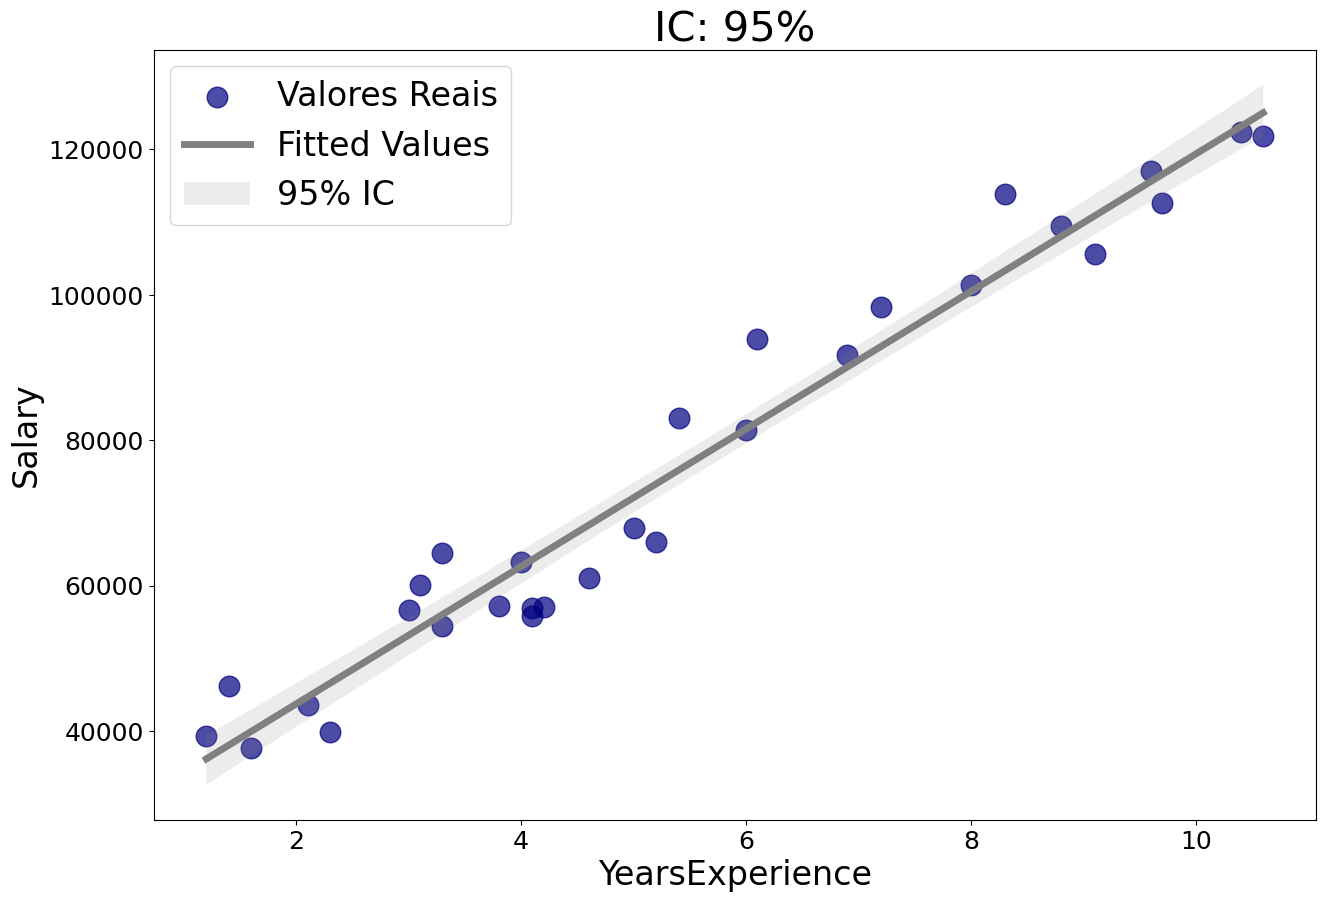

In [34]:
plt.figure(figsize=(15,10))
sns.regplot(data=data, x='YearsExperience', y='Salary', marker='o', ci=95,
            scatter_kws={"color":'navy', 'alpha':0.7, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('IC: 95%', fontsize=30)
plt.xlabel('YearsExperience', fontsize=24)
plt.ylabel('Salary', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(['Valores Reais', 'Fitted Values', '95% IC'],
           fontsize=24, loc='upper left')
plt.show()

In [37]:
X = data[['YearsExperience']]
y = data['Salary']

mod = LinearRegression().fit(X, y)

In [39]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.14e-20
Time:                        23:51:54   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        2.485e+04   2306.654     

In [ ]:
X_sm = sm.add_constant(X)  # adiciona intercepto
model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.14e-20
Time:                        23:51:20   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.485e+04   2306.654     